In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os
import pandas as pd

import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

In [2]:
folder = "/home/remi/UltimateEPM/build/bulk_amc_Si_electron_T300.0_Ex0.000e+00"
files = glob.glob(
    os.path.join(folder, "*_particle_*.csv")
)
print(f"Found {len(files)} files.")
files = np.random.choice(files, size=10, replace=False)

Found 500 files.


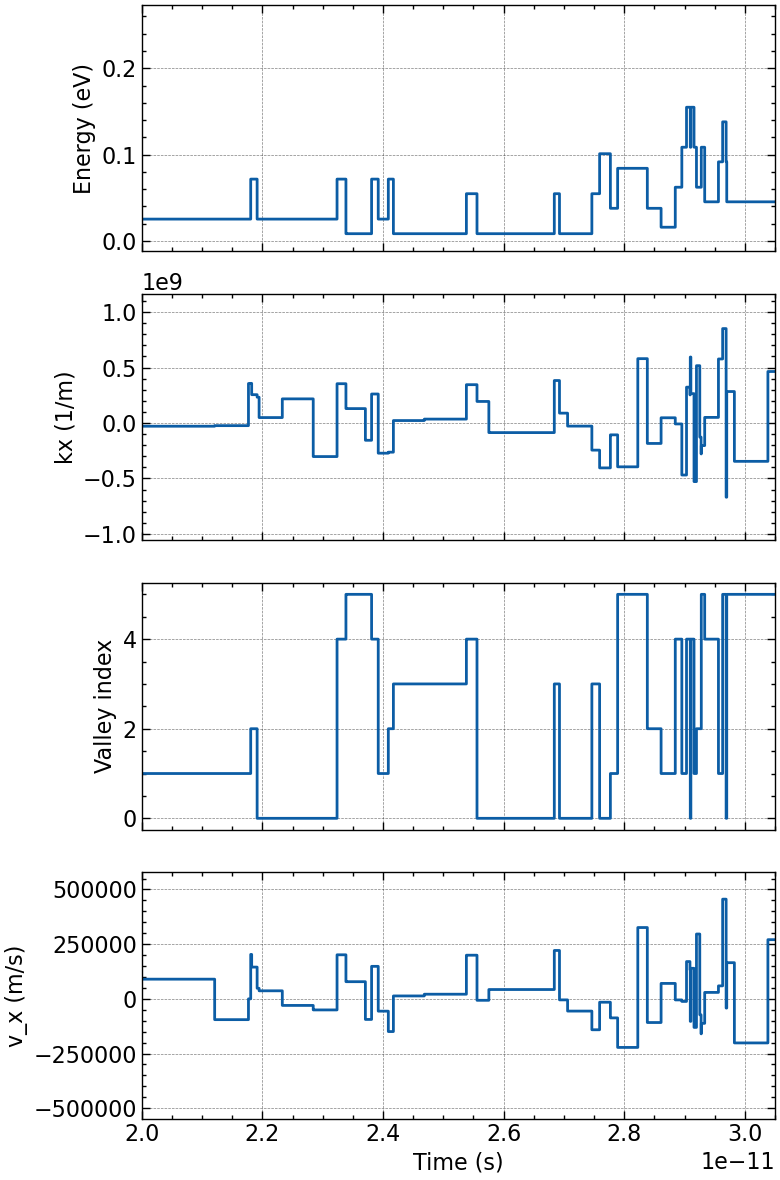

In [3]:
NParticlePlots = 1

fig, axs = plt.subplots(4, 1, figsize=(8, 12), sharex=True)
for i, file in enumerate(files[:NParticlePlots]):
    data = pd.read_csv(file)
    time,X,Y,Z,kx,ky,kz,v_x,v_y,v_z,energy,gamma,valley_index = data.columns
    
    axs[0].plot(data[time], data[energy], label=f"Particle {i}")
    axs[1].plot(data[time], data[kx], label=f"Particle {i}")
    axs[2].plot(data[time], data[valley_index], label=f"Particle {i}")
    axs[3].plot(data[time], data[v_x], label=f"Particle {i}")
    
tmin, tmax = 20e-12, 30.5e-12
axs[0].set_xlim(tmin, tmax)
axs[-1].set_xlabel("Time (s)")
axs[0].set_ylabel("Energy (eV)")
axs[1].set_ylabel("kx (1/m)")
axs[2].set_ylabel("Valley index")
axs[3].set_ylabel("v_x (m/s)")
plt.tight_layout()
plt.show()

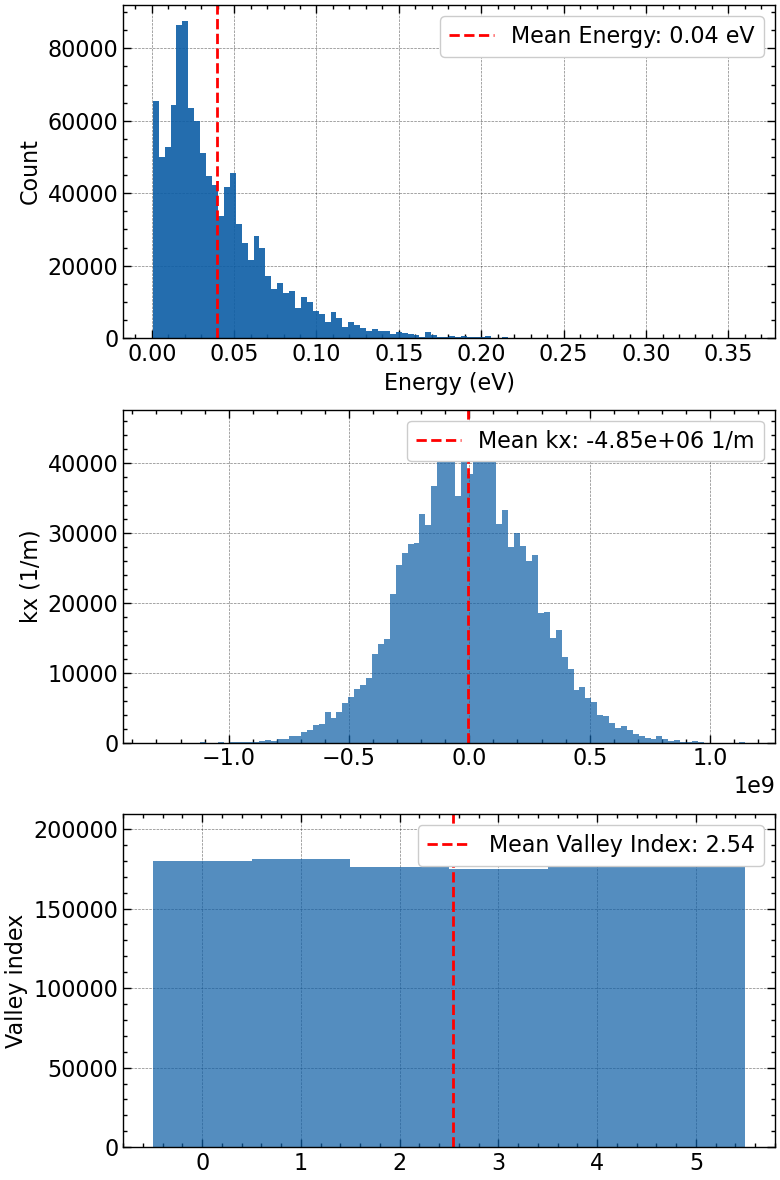

In [4]:
NParticlePlots = 4000
NParticlePlots = min(NParticlePlots, len(files))

all_energies = []
all_kx = []
all_valley_indices = []

ratio_warmup = 0.2
warmup_arg_time = int(ratio_warmup * len(data[time]))

# Loop over the files and collect data for all particles
for i, file in enumerate(files[:NParticlePlots]):
    data = pd.read_csv(file)
    time,X,Y,Z,kx,ky,kz,v_x,v_y,v_z,energy,gamma,valley_index = data.columns
    all_energies.append(data[energy][warmup_arg_time:])
    all_kx.append(data[kx][warmup_arg_time:])
    all_valley_indices.append(data[valley_index][warmup_arg_time:])

# Flatten the lists of arrays into single arrays for plotting
all_energies = np.concatenate(all_energies)
all_kx = np.concatenate(all_kx)
all_valley_indices = np.concatenate(all_valley_indices)
    
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=False)

# Plot histograms of energies, kx, and valley indices for all particles
axs[0].hist(all_energies, bins=100, alpha=0.9)
axs[1].hist(all_kx, bins=100, alpha=0.7)
axs[2].hist(all_valley_indices, bins=np.arange(-0.5, np.max(all_valley_indices)+1.5, 1), alpha=0.7)

# Mean values for reference
mean_energy = np.mean(all_energies)
mean_kx = np.mean(all_kx)
mean_valley_index = np.mean(all_valley_indices)
axs[0].axvline(mean_energy, color='r', linestyle='dashed', label=f'Mean Energy: {mean_energy:.2f} eV')
axs[1].axvline(mean_kx, color='r', linestyle='dashed', label=f'Mean kx: {mean_kx:.2e} 1/m')
axs[2].axvline(mean_valley_index, color='r', linestyle='dashed', label=f'Mean Valley Index: {mean_valley_index:.2f}')
axs[0].legend()
axs[1].legend()
axs[2].legend()

axs[0].set_xlabel("Energy (eV)")
axs[0].set_ylabel("Count")
axs[1].set_ylabel("kx (1/m)")
axs[2].set_ylabel("Valley index")
plt.tight_layout()
plt.show()
